<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/LSTM_Heartbeat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RNNs & LSTMs for Sequential Data**

-------

# **Introduction**



An Electrocardiogram (ECG) records the electrical activity of the heart over time as a sequence of signal values. Each heartbeat has a specific waveform, and changes in the shape and timing of these signals can indicate different types of cardiac abnormalities. Since ECG signals are sequential, the order of the values is important when trying to understand the pattern of a heartbeat.

In this notebook, we will use a **Long Short-Term Memory (LSTM)** neural network to classify ECG heartbeat signals. LSTMs are a type of Recurrent Neural Network (RNN) designed for sequential data. Unlike traditional neural networks that treat inputs more independently, an LSTM processes a sequence step by step while maintaining information from previous points in the sequence. This makes it suitable for learning patterns that develop across an ECG signal.

## Dataset

For this task, we use the **MIT-BIH Arrhythmia Database**, provided through the Kaggle Heartbeat dataset. Each heartbeat is represented by a sequence of **187 signal values**, followed by a class label.

The model will classify each heartbeat into one of five categories:

* **Normal heartbeat**
* **Supraventricular abnormal heartbeat**
* **Ventricular abnormal heartbeat**
* **Fusion heartbeat**
* **Unknown or unclassifiable heartbeat**

Because the dataset is sequential, we will preserve the order of the ECG signal values and reshape the data into the format expected by an LSTM: **samples, timesteps, and features**.

## Goals of This Notebook

Throughout the notebook, we will:

1. Prepare and explore the ECG sequential data.
2. Build and train an **LSTM model** for heartbeat classification.
3. Evaluate the model using accuracy, a classification report, and a confusion matrix.
4. Build a **plain RNN** and compare its performance with the LSTM.
5. Explain why order-awareness and memory are important when working with ECG signals.


-------


# **Section 1 : Building and Evaluating an LSTM Model**

## 1. Mount Drive & unzip the dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import zipfile

zip_path = "/content/drive/MyDrive/Datasets/Heartbeat Categorization Dataset/Heartbeat Categorization Dataset.zip"   # path in drive
extract_path = "/content/heartbeat_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

import os
print(os.listdir(extract_path))

['ptbdb_normal.csv', 'mitbih_test.csv', 'mitbih_train.csv', 'ptbdb_abnormal.csv']


> ['ptbdb_normal.csv', 'mitbih_test.csv', 'mitbih_train.csv', 'ptbdb_abnormal.csv']

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2.Data Loading and Reshaping

Format 1D sequence data for recurrent layers.The dataset contains ECG values (187 sequence points) with the 188th column representing the class label (0 to 4 for MIT-BIH dataset).Recurrent layers in Keras expect 3D input tensors with shape: (batch_size, timesteps, features).

### Load the training and testing data

In [14]:
train_path = '/content/heartbeat_data/mitbih_train.csv'
test_path = '/content/heartbeat_data/mitbih_test.csv'

train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (87554, 188)
Testing shape: (21892, 188)


### Understanding the Dataset

Each row represents one ECG heartbeat.

The dataset contains 188 columns:

- The first 187 columns contain ECG signal values.
- The final column contains the class label.

Therefore, each heartbeat can be treated as a sequence of 187 values.

This makes the dataset suitable for an LSTM because the order of the ECG values matters.
The LSTM processes the signal step-by-step and can learn patterns that occur across different parts of the heartbeat.

## 3. Separate X (features) and y (lables)

In [15]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (87554, 187)
y_train: (87554,)
X_test: (21892, 187)
y_test: (21892,)


## 4. Look at the classes Balances

Training class distribution:
0    72471
1     2223
2     5788
3      641
4     6431
Name: count, dtype: int64


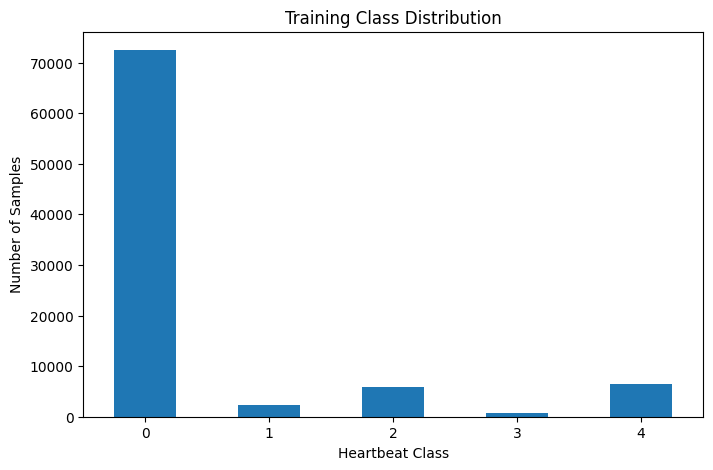

In [16]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

plt.figure(figsize=(8, 5))

pd.Series(y_train).value_counts().sort_index().plot(kind='bar')

plt.title("Training Class Distribution")
plt.xlabel("Heartbeat Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

The 'Training Class Distribution' plot clearly shows a significant class imbalance. Class 0 is by far the most represented class with 72,471 samples. The other classes (1, 2, 3, and 4) have significantly fewer samples: Class 1 has 2,223 samples, Class 2 has 5,788 samples, Class 3 has only 641 samples, and Class 4 has 6,431 samples. This imbalance might need to be addressed during model training to prevent the model from being biased towards the majority class.

### Visualize actual ECG sequences

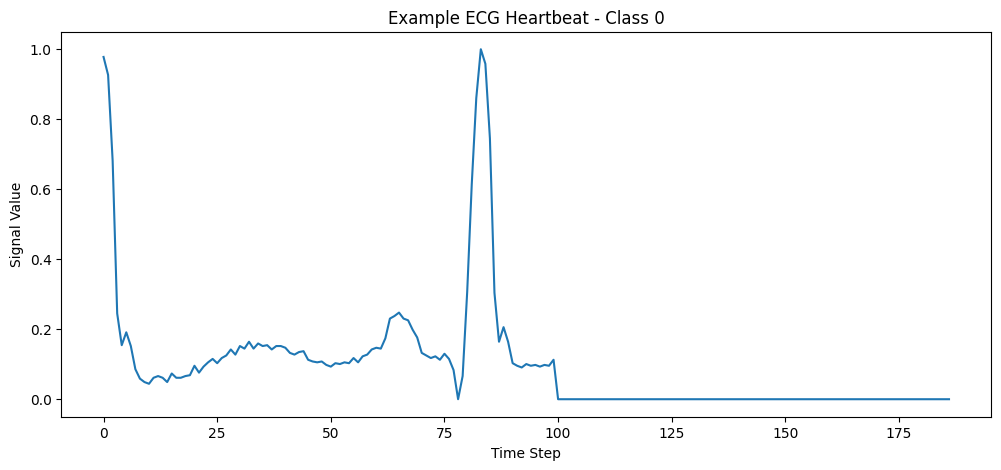

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(X_train[0])

plt.title(f"Example ECG Heartbeat - Class {y_train[0]}")
plt.xlabel("Time Step")
plt.ylabel("Signal Value")

plt.show()

> Unlike an ordinary tabular feature vector, these 187 values have an order. They represent consecutive points in an ECG signal.

## 5. Reshape the data for the LSTM



### Reshaping for LSTM

An LSTM expects sequential data in the form:

(samples, timesteps, features)

For this dataset:

- samples = number of heartbeats
- timesteps = 187 ECG signal points
- features = 1 signal value at each time step

Therefore, the input shape becomes:

(87554, 187, 1)

In [18]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (87554, 187, 1)
X_test shape: (21892, 187, 1)


## 6. Building the LSTM model

Model architecture:

```text
ECG sequence
     ↓
LSTM(64)
     ↓
Dropout(0.3)
     ↓
Dense(32, ReLU)
     ↓
Dense(5, Softmax)
     ↓
5 heartbeat classes
```

`LSTM(64)` : The LSTM has 64 units that processe the ECG sequence one timestep at a time while maintaining internal states that carry information through the sequence.

In [19]:
model_lstm = Sequential([
    LSTM(64, input_shape=(187, 1)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_lstm.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,141 (74.77 KB)

 Trainable params: 19,141 (74.77 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile the model

In [20]:
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 8. Dealing with the class imbalance

In [23]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int64(0): np.float64(0.24162492583240192), np.int64(1): np.float64(7.877103013945119), np.int64(2): np.float64(3.0253628196268143), np.int64(3): np.float64(27.317940717628705), np.int64(4): np.float64(2.7228735810915876)}


## 9. Training the model

In [27]:
history = model_lstm.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128, # because the dataset is large
    class_weight=class_weights,
    verbose=1
)

Epoch 1/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6376 - loss: 0.6460 - val_accuracy: 0.0000e+00 - val_loss: 8.1321
Epoch 2/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6155 - loss: 0.6445 - val_accuracy: 0.0000e+00 - val_loss: 6.5454
Epoch 3/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6293 - loss: 0.6452 - val_accuracy: 0.0050 - val_loss: 7.2852
Epoch 4/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7326 - loss: 0.6380 - val_accuracy: 0.0170 - val_loss: 7.3230
Epoch 5/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7605 - loss: 0.6345 - val_accuracy: 0.0249 - val_loss: 7.4394
Epoch 6/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7387 - loss: 0.6362 - val_accuracy: 0.0000e+00 - val_loss: 10.0439
Epoch 7/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7370 - loss: 0.6387 - val_accuracy: 0.0279 - val_loss: 8.0183
Epoch 8/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5480 - loss: 0.61

## 10. Plot training and validation loss

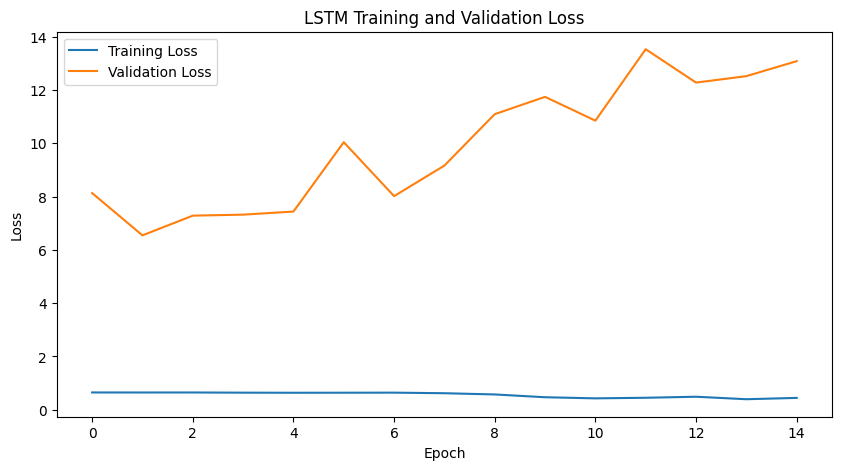

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Analysing the diagram

The training accuracy is al,ost the same with every epic but the validation accuracy is getting higher which shows overfitting


## 11. Evaluate the model

In [29]:
test_loss, test_accuracy = model_lstm.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7765 - loss: 1.7976
Test Loss: 1.7976338863372803
Test Accuracy: 0.7765393853187561


The model achieved a **77.65% test accuracy** and a **1.7976 test loss**.


* **Test Loss (1.7976):** A high loss value shows the model struggles to generalize to new data, likely due to overfitting during training.
* **Test Accuracy (77.65%):** While nearly 78% correct sounds good, this number is misleading because the dataset is imbalanced. A model can score high simply by guessing the most common heart class every time.



## 12. Generate predictions

In [30]:
y_pred_prob = model_lstm.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print(y_pred[:20])

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
[0 0 0 0 2 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]


## 13. Classification report & Confusion matrix

In [31]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Normal',
            'Supraventricular',
            'Ventricular',
            'Fusion',
            'Unknown'
        ]
    )
)

                  precision    recall  f1-score   support

          Normal       0.95      0.86      0.90     18118
Supraventricular       0.18      0.65      0.28       556
     Ventricular       0.30      0.70      0.42      1448
          Fusion       0.00      0.00      0.00       162
         Unknown       0.00      0.00      0.00      1608

        accuracy                           0.78     21892
       macro avg       0.29      0.44      0.32     21892
    weighted avg       0.81      0.78      0.78     21892



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Overall, while the accuracy (0.78) is seemingly decent, the macro avg F1-score (0.32) highlights that the model struggles significantly with minority classes, and mainly performs well on the abundant 'Normal' class. This confirms the impact of the class imbalance we observed earlier.

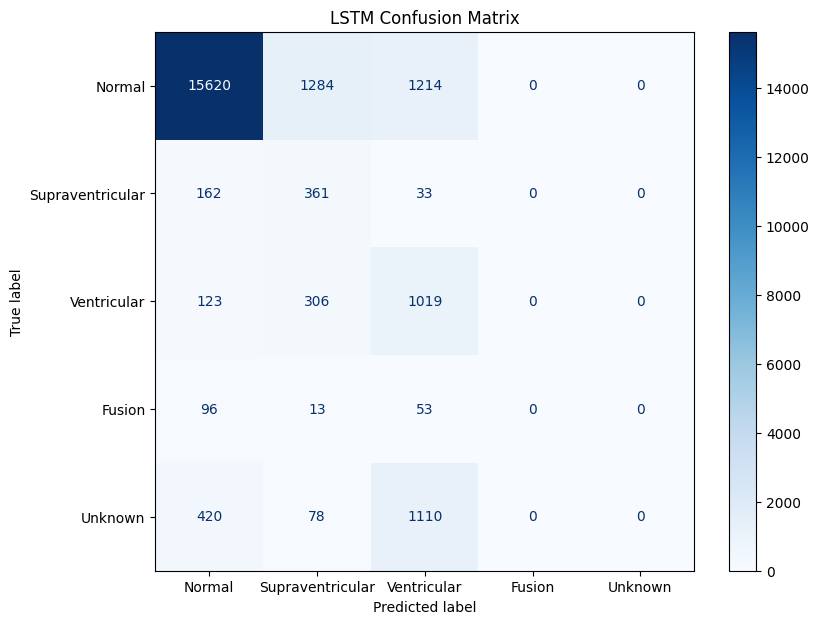

In [33]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Normal',
        'Supraventricular',
        'Ventricular',
        'Fusion',
        'Unknown'
    ]
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(ax=ax, cmap=plt.cm.Blues)

plt.title("LSTM Confusion Matrix")
plt.show()

### Confusion Matrix Summary

The confusion matrix shows that the model performs well mainly on the **Normal** class, but struggles to distinguish the minority heartbeat classes. It correctly identifies many Normal heartbeats, while **Supraventricular and Ventricular** heartbeats are often confused with each other or with the Normal class. The model performs particularly poorly on **Fusion and Unknown** heartbeats, failing to correctly identify any samples from these classes.

Overall, the results show that the model is strongly affected by the **class imbalance** in the dataset. Although it can recognize the dominant class reasonably well, it has difficulty learning reliable patterns for rare heartbeat types. This highlights why accuracy alone is not enough to evaluate this model and why **recall and F1-score for minority classes** are especially important.


----------

# **Section 2: Building an RNN**

In [34]:
from tensorflow.keras.layers import SimpleRNN

model_rnn = Sequential([
    SimpleRNN(64, input_shape=(187, 1)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_rnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,469 (25.27 KB)

 Trainable params: 6,469 (25.27 KB)

 Non-trainable params: 0 (0.00 B)

## 2. Training the RNN Model

In [36]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.5205 - loss: 0.6667 - val_accuracy: 0.0933 - val_loss: 6.6635
Epoch 2/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.4719 - loss: 0.6540 - val_accuracy: 0.0000e+00 - val_loss: 7.9429
Epoch 3/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.5168 - loss: 0.6559 - val_accuracy: 0.0000e+00 - val_loss: 7.3942
Epoch 4/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4186 - loss: 0.6351 - val_accuracy: 0.0162 - val_loss: 3.9767
Epoch 5/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3750 - loss: 0.6495 - val_accuracy: 4.5683e-04 - val_loss: 8.1235
Epoch 6/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.3534 - loss: 0.6336 - val_accuracy: 0.0000e+00 - val_loss: 7.3331
Epoch 7/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4851 - loss: 0.6375 - val_accuracy: 0.0751 - val_loss: 7.8379
Epoch 8/15
616/616 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4759 - 

## 3. Evaluate the RNN

In [37]:
rnn_loss, rnn_accuracy = model_rnn.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("RNN Test Loss:", rnn_loss)
print("RNN Test Accuracy:", rnn_accuracy)

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7428 - loss: 1.7583
RNN Test Loss: 1.7583130598068237
RNN Test Accuracy: 0.7428284287452698


# **Comparing the RNN and LSTM**

In [38]:
comparison = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM'],
    'Test Accuracy': [rnn_accuracy, test_accuracy],
    'Test Loss': [rnn_loss, test_loss]
})

comparison

,Model,Test Accuracy,Test Loss
0,Simple RNN,0.742828,1.758313
1,LSTM,0.776539,1.797634


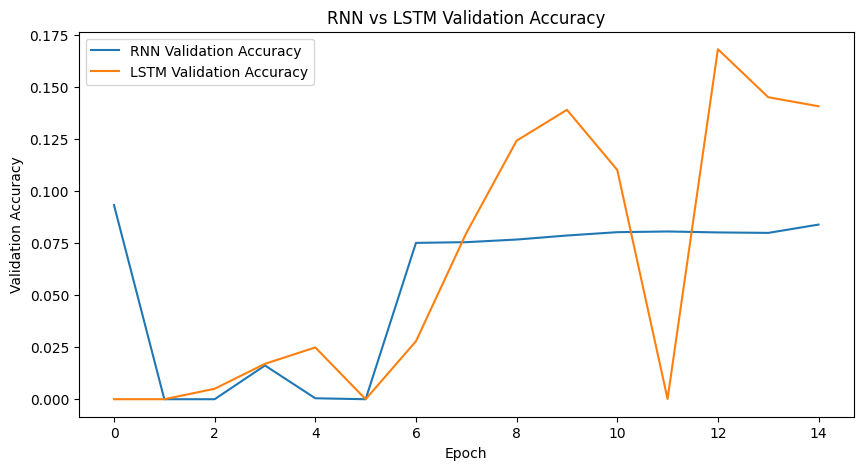

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_rnn.history['val_accuracy'],
    label='RNN Validation Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='LSTM Validation Accuracy'
)

plt.title("RNN vs LSTM Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

Based on the overall test accuracy, the LSTM model performed better, achieving a higher percentage of correct classifications on the test set. Although its test loss was marginally higher, its superior accuracy suggests it was more effective at distinguishing between the different heartbeat classes. However, it's important to reiterate the earlier observation about class imbalance and the LSTM's poor performance on minority classes, which should be investigated further for a more robust model.

------------

## Why Order-Awareness Helped

The ECG data is sequential because each value represents a point in the heartbeat signal, and the order of these points forms the shape of the heartbeat.

A normal Dense network would treat the input values more like independent features. An RNN or LSTM processes them in sequence and can use information from earlier points when processing later points.

The LSTM is especially useful because its memory cells and gates allow it to decide which information should be kept and which information should be forgotten.

Therefore, the model can learn patterns across the ECG sequence instead of only looking at individual signal values.

# **References**

- [This vedio explains RNN problem, the vanishing gradeient, and LSTM](https://www.youtube.com/watch?v=VJHWOO2Ix_8)

- [Codes for an LSTM project](https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-lstm-rnn-in-tensorflow/)

- [Text Classification Readings](https://deeplearningwithpython.io/chapters/chapter14_text-classification/)